In [55]:
import os
import pandas as pd
import numpy as np

In [56]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 116000,
    "squadv2": 130000,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [57]:
prompt_type = "direct_qa"

In [58]:
def extract_alpha(str):
    # use regex to extract the number after "alpha="
    import re
    match = re.search(r"alpha=([\d.]+),", str)
    if match:        return float(match.group(1))
    else:        return None    

def extract_beta(str):
    # use regex to extract the number after "beta="
    import re
    match = re.search(r"beta=([\d.]+),", str)
    if match:        return float(match.group(1))
    else:        return None   

In [ ]:
results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/direct_qa_in_domain_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

all_records = []
for leaf_dir in leaf_dirs:
    _, _, _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
    if os.path.exists(os.path.join(leaf_dir, "calibration_details.csv")):
        csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"))

        original_alpha = csv_data["original_lc"].apply(extract_alpha)
        original_beta = csv_data["original_lc"].apply(extract_beta)
        lc_calibrated_alpha = csv_data["calibrated_lc_rewritten_lc"].apply(extract_alpha)
        lc_calibrated_beta = csv_data["calibrated_lc_rewritten_lc"].apply(extract_beta)
        tp_calibrated_alpha = csv_data["calibrated_tp_rewritten_lc"].apply(extract_alpha)
        tp_calibrated_beta = csv_data["calibrated_tp_rewritten_lc"].apply(extract_beta)
        su_calibrated_alpha = csv_data["calibrated_su_rewritten_lc"].apply(extract_alpha)
        su_calibrated_beta = csv_data["calibrated_su_rewritten_lc"].apply(extract_beta)
        accuracy = csv_data["accuracy"].tolist()

        record = {
            "model_name": model_name_map.get(model_name, model_name),
            "dataset_name": dataset_map.get(dataset_name, dataset_name),
            "original_alpha": original_alpha,
            "original_beta": original_beta,
            "lc_calibrated_alpha": lc_calibrated_alpha,
            "lc_calibrated_beta": lc_calibrated_beta,
            "tp_calibrated_alpha": tp_calibrated_alpha,
            "tp_calibrated_beta": tp_calibrated_beta,
            "su_calibrated_alpha": su_calibrated_alpha,
            "su_calibrated_beta": su_calibrated_beta,
            "accuracy": accuracy
        }

        all_records.append(record)

    else:
        print(model_name, dataset_name, "missing calibration_details.pkl")

in_domain_reliability_diagrams_truthfulqa.pdf


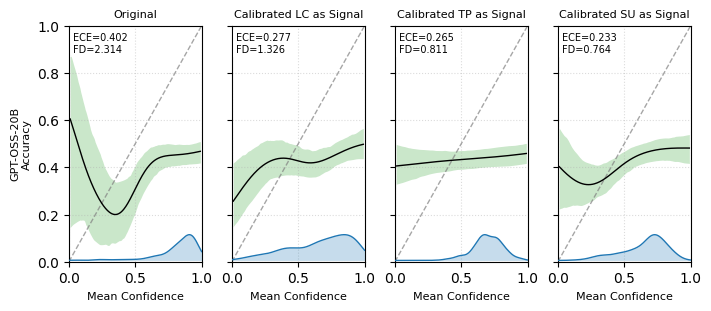

Saved files:


In [60]:
import os
import matplotlib.pyplot as plt
from scipy.special import betaln, psi
from scipy.stats import gaussian_kde


def _equal_mass_bins(values, num_bins):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.linspace(0.0, 1.0, num_bins + 1)
    quantiles = np.linspace(0.0, 1.0, num_bins + 1)
    edges = np.quantile(values, quantiles)
    edges = np.clip(edges, 0.0, 1.0)
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = min(1.0, edges[i - 1] + 1e-6)
    if edges[-1] < 1.0:
        edges[-1] = 1.0
    if np.unique(edges).size < 2:
        return np.linspace(0.0, 1.0, num_bins + 1)
    return edges


def _density_from_equal_mass(values, num_bins):
    bins = _equal_mass_bins(values, num_bins)
    counts, _ = np.histogram(values, bins=bins)
    widths = np.diff(bins)
    total = counts.sum()
    if total <= 0:
        return None, None
    density = counts / (total * widths)
    centers = (bins[:-1] + bins[1:]) / 2.0
    return centers, density


# ---------------------------------------------------------------------------
# Nadaraya-Watson helpers (Gaussian kernel)
# ---------------------------------------------------------------------------

def _nw_smooth(c, mu, y, h):
    """NW estimator: r_hat(c). c:(M,), mu:(N,), y:(N,) -> (M,)."""
    diff = (c[:, None] - mu[None, :]) / h       # (M, N)
    K    = np.exp(-0.5 * diff ** 2)
    return (K @ y) / K.sum(axis=1).clip(1e-8)


def _loo_mse(h, mu, y):
    diff = (mu[:, None] - mu[None, :]) / h
    K    = np.exp(-0.5 * diff ** 2)
    np.fill_diagonal(K, 0.0)
    y_hat = (K @ y) / K.sum(axis=1).clip(1e-8)
    return float(np.mean((y - y_hat) ** 2))


def _select_bandwidth(mu, y):
    h_grid = np.logspace(-2, np.log10(0.5), 40)
    mse    = [_loo_mse(h, mu, y) for h in h_grid]
    return float(h_grid[int(np.argmin(mse))])


# ---------------------------------------------------------------------------
# Utilities shared across panels
# ---------------------------------------------------------------------------

def _clean_accuracy(values):
    cleaned = []
    for val in values:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            continue
        if val == "":
            val = 0.0
        try:
            cleaned.append(float(val))
        except (ValueError, TypeError):
            continue
    return np.asarray(cleaned, dtype=float)


def _align_and_clean(alpha_vals, beta_vals, accuracy_vals):
    a = np.asarray(alpha_vals, dtype=float)
    b = np.asarray(beta_vals,  dtype=float)
    y = np.asarray(accuracy_vals, dtype=float)
    n = min(len(a), len(b), len(y))
    a, b, y = a[:n], b[:n], y[:n]
    mask = np.isfinite(a) & np.isfinite(b) & np.isfinite(y) & (a > 0) & (b > 0)
    return a[mask], b[mask], y[mask]


def _generalised_ece_scalar(alpha_vals, beta_vals, accuracy_vals,
                             num_bins=10, num_samples=1500, seed=None):
    """Return scalar gECE only (bin-based, not used for plotting)."""
    a, b, y = _align_and_clean(alpha_vals, beta_vals, accuracy_vals)
    if len(y) == 0:
        return np.nan
    rng         = np.random.default_rng(seed)
    all_samples = rng.beta(a[:, None], b[:, None], size=(len(y), num_samples))
    bins        = np.linspace(0.0, 1.0, num_bins + 1)
    bin_indices = np.clip(np.digitize(all_samples, bins) - 1, 0, num_bins - 1)
    gece = 0.0
    for m in range(num_bins):
        p_nm = np.mean(bin_indices == m, axis=1)
        pm   = p_nm.sum()
        if pm <= 0:
            continue
        rm = np.sum(p_nm * y) / pm
        gm = all_samples[bin_indices == m].mean() if (bin_indices == m).any() else 0.0
        gece += (pm / len(y)) * abs(rm - gm)
    return float(gece)


def _faithfulness_divergence(alpha_vals, beta_vals, accuracy_vals):
    a, b, y = _align_and_clean(alpha_vals, beta_vals, accuracy_vals)
    if len(y) == 0:
        return np.nan
    a_post = a + y; b_post = b + (1.0 - y)
    kl = (betaln(a, b) - betaln(a_post, b_post)
          + (a_post - a) * psi(a_post)
          + (b_post - b) * psi(b_post)
          - (a_post + b_post - a - b) * psi(a_post + b_post))
    fd = np.maximum(0.0, (a + b + 1e-8) * kl)
    fd = fd[np.isfinite(fd)]
    return float(np.mean(fd)) if len(fd) > 0 else np.nan


def _add_density_strip(ax, alpha_vals, beta_vals, color="#1f77b4"):
    a = np.asarray(alpha_vals, dtype=float)
    b = np.asarray(beta_vals,  dtype=float)
    mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
    if mask.sum() < 2:
        return
    mu      = a[mask] / (a[mask] + b[mask])
    kde     = gaussian_kde(mu, bw_method="scott")
    x_kde   = np.linspace(0.0, 1.0, 300)
    density = kde(x_kde)
    ax_ins  = ax.inset_axes([0.0, 0.0, 1.0, 0.12])
    ax_ins.plot(x_kde, density, color=color, lw=1.0)
    ax_ins.fill_between(x_kde, density, alpha=0.25, color=color, linewidth=0)
    ax_ins.set_xlim(0, 1)
    ax_ins.axis("off")


def _plot_reliability_diagram(ax, alpha_vals, beta_vals, accuracy_vals, panel_title,
                               n_bootstrap=300, ci_percentiles=(2.5, 97.5)):
    a, b, y = _align_and_clean(alpha_vals, beta_vals, accuracy_vals)
    ece     = _generalised_ece_scalar(alpha_vals, beta_vals, accuracy_vals)
    fd      = _faithfulness_divergence(alpha_vals, beta_vals, accuracy_vals)

    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.7, linewidth=1)

    if len(y) > 1:
        mus    = a / (a + b)
        h      = max(_select_bandwidth(mus, y), 0.1)
        c_grid = np.linspace(0.01, 0.99, 200)
        r_hat  = _nw_smooth(c_grid, mus, y, h)

        rng         = np.random.default_rng()
        boot_curves = np.empty((n_bootstrap, len(c_grid)))
        for k in range(n_bootstrap):
            idx             = rng.integers(0, len(y), size=len(y))
            boot_curves[k]  = _nw_smooth(c_grid, mus[idx], y[idx], h)
        lower = np.percentile(boot_curves, ci_percentiles[0], axis=0)
        upper = np.percentile(boot_curves, ci_percentiles[1], axis=0)

        ax.fill_between(c_grid, lower, upper,
                        color="#2ca02c", alpha=0.25, linewidth=0)
        ax.plot(c_grid, r_hat, color="black", lw=1.0)

    _add_density_strip(ax, alpha_vals, beta_vals)

    ax.text(0.03, 0.97,
            f"ECE={ece:.3f}\nFD={fd:.3f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=7,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 2.0})
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", alpha=0.45)
    ax.set_title(panel_title, fontsize=8)


if len(all_records) == 0:
    raise ValueError("No records found. Run the data-loading cell first.")

num_cols = 4
dataset_groups = {}
for rec in all_records:
    dataset_groups.setdefault(rec["dataset_name"], []).append(rec)

saved_paths = []
for dataset_name in sorted(dataset_groups.keys()):
    dataset_records = dataset_groups[dataset_name]
    num_rows = len(dataset_records)

    fig, axes = plt.subplots(
        num_rows, num_cols,
        figsize=(1.75 * num_cols, max(1.75 * num_rows, 3.0)),
        squeeze=False, sharex=True, sharey=True, constrained_layout=True,
    )

    for r, record in enumerate(dataset_records):
        y = _clean_accuracy(record["accuracy"])
        panel_data = [
            (record["original_alpha"],      record["original_beta"],      "Original"),
            (record["lc_calibrated_alpha"], record["lc_calibrated_beta"], "Calibrated LC as Signal"),
            (record["tp_calibrated_alpha"], record["tp_calibrated_beta"], "Calibrated TP as Signal"),
            (record["su_calibrated_alpha"], record["su_calibrated_beta"], "Calibrated SU as Signal"),
        ]
        for c, (a_vals, b_vals, panel_name) in enumerate(panel_data):
            ax = axes[r, c]
            _plot_reliability_diagram(ax, a_vals, b_vals, y, panel_name)
            if c == 0:
                ax.set_ylabel(f"{record['model_name']}\nAccuracy", fontsize=8)
            ax.set_xlabel("Mean Confidence", fontsize=8)

    safe_name = str(dataset_name).lower().replace(" ", "_").replace("/", "-")
    out_path  = f"in_domain_reliability_diagrams_{safe_name}.pdf"
    # fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(out_path)
    plt.show()
    plt.close(fig)

print("Saved files:")
for path in saved_paths:
    print(path)
